In [1]:
import nltk
import pandas as pd

In [2]:
df = pd.read_csv('/kaggle/input/text-document-classification-dataset/df_file.csv')
df

,Text,Label
0,Budget to set scene for election\n \n Gordon B...,0
1,Army chiefs in regiments decision\n \n Militar...,0
2,Howard denies split over ID cards\n \n Michael...,0
3,Observers to monitor UK election\n \n Minister...,0
4,Kilroy names election seat target\n \n Ex-chat...,0
...,...,...
2220,India opens skies to competition\n \n India wi...,4
2221,Yukos bankruptcy 'not US matter'\n \n Russian ...,4
2222,Survey confirms property slowdown\n \n Governm...,4
2223,High fuel prices hit BA's profits\n \n British...,4


Let's clean the data by checking for various anomalies

In [3]:
df.duplicated().sum()

98

In [4]:
df.isnull().sum()

Text     0
Label    0
dtype: int64

In [5]:
# checking for any blank entries, i.e., they contain whitespace only

blanks = []

for i,lb,rv in df.itertuples():
    if type(rv)==str:
        if rv.isspace():
            blanks.append(i)
        
print(len(blanks), 'blanks: ', blanks)

0 blanks:  []


In [6]:
df = df.drop_duplicates(keep = 'first')

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2127 entries, 0 to 2224
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   Text    2127 non-null   object
 1   Label   2127 non-null   int64 
dtypes: int64(1), object(1)
memory usage: 49.9+ KB


In [8]:
df.reset_index(drop = True)

,Text,Label
0,Budget to set scene for election\n \n Gordon B...,0
1,Army chiefs in regiments decision\n \n Militar...,0
2,Howard denies split over ID cards\n \n Michael...,0
3,Observers to monitor UK election\n \n Minister...,0
4,Kilroy names election seat target\n \n Ex-chat...,0
...,...,...
2122,India opens skies to competition\n \n India wi...,4
2123,Yukos bankruptcy 'not US matter'\n \n Russian ...,4
2124,Survey confirms property slowdown\n \n Governm...,4
2125,High fuel prices hit BA's profits\n \n British...,4


In [9]:
df.Label.value_counts()

Label
1    505
4    503
0    403
3    369
2    347
Name: count, dtype: int64

In [10]:
df.Text[1498]

'Bollywood DVD fraudster is jailed\n \n A major distributor of pirated DVDs of Bollywood films has been sent to prison for three years.\n \n Jayanti Amarishi Buhecha from Cambridge was found guilty of two trademark offences last month, and sentenced at Harrow Crown Court, London, on Tuesday. Buhecha, who made Â£26,000 per month from his illegal trade, was called "one of the biggest Bollywood pirates in the UK" by the sentencing judge. The British Phonographic Industry (BPI) worked for two years on the case.\n \n An operation was launched against Buhecha in 2002 after complaints were received about his activities. The judge in the case, which lasted seven days, said that "a heavy penalty was called for because of the enormous damage Buhecha caused to legitimate business". Fake DVDs were manufactured in Pakistan and Malaysia and sold on wholesale to shops by Buhecha, who traded in conterfeit DVDs in 2002 and 2003.\n \n In December 2002, he was stopped in his car by trading standards offi

In [11]:
df.Label[1498]

3

This looks like entertainment and it is

## Text Preprocessing

In [12]:
import string
import re
exclude = string.punctuation

def preprocess(text):
    for char in exclude:
        text = text.replace(char,'')
        text = re.sub(r'\n', '', text)
        text = re.sub(r'\s+', ' ', text)
    return text

df['Text'] = df['Text'].apply(preprocess)

<ipython-input-12-3a92b34e6d09>:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Text'] = df['Text'].apply(preprocess)


In [13]:
df['Text'] = df['Text'].str.lower()

<ipython-input-13-51ee18179c24>:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Text'] = df['Text'].str.lower()


In [14]:
df

,Text,Label
0,budget to set scene for election gordon brown ...,0
1,army chiefs in regiments decision military chi...,0
2,howard denies split over id cards michael howa...,0
3,observers to monitor uk election ministers wil...,0
4,kilroy names election seat target exchat show ...,0
...,...,...
2220,india opens skies to competition india will al...,4
2221,yukos bankruptcy not us matter russian authori...,4
2222,survey confirms property slowdown government f...,4
2223,high fuel prices hit bas profits british airwa...,4


In [15]:
df['Text'][1498]

'bollywood dvd fraudster is jailed a major distributor of pirated dvds of bollywood films has been sent to prison for three years jayanti amarishi buhecha from cambridge was found guilty of two trademark offences last month and sentenced at harrow crown court london on tuesday buhecha who made â£26000 per month from his illegal trade was called one of the biggest bollywood pirates in the uk by the sentencing judge the british phonographic industry bpi worked for two years on the case an operation was launched against buhecha in 2002 after complaints were received about his activities the judge in the case which lasted seven days said that a heavy penalty was called for because of the enormous damage buhecha caused to legitimate business fake dvds were manufactured in pakistan and malaysia and sold on wholesale to shops by buhecha who traded in conterfeit dvds in 2002 and 2003 in december 2002 he was stopped in his car by trading standards officers who uncovered 1000 pirated dvds and fa

In [16]:
import spacy
nlp = spacy.load('en_core_web_sm')

In [17]:
def lemmatize_text(text):
    doc = nlp(text)
    return " ".join([token.lemma_ for token in doc])

df['Text'] = df['Text'].apply(lemmatize_text)

<ipython-input-17-ca236069bd53>:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Text'] = df['Text'].apply(lemmatize_text)


In [18]:
df['Text'][1498]

'bollywood dvd fraudster be jail a major distributor of pirate dvds of bollywood film have be send to prison for three year jayanti amarishi buhecha from cambridge be find guilty of two trademark offence last month and sentence at harrow crown court london on tuesday buhecha who make â£26000 per month from his illegal trade be call one of the big bollywood pirate in the uk by the sentencing judge the british phonographic industry bpi work for two year on the case an operation be launch against buhecha in 2002 after complaint be receive about his activity the judge in the case which last seven day say that a heavy penalty be call for because of the enormous damage buhecha cause to legitimate business fake dvds be manufacture in pakistan and malaysia and sell on wholesale to shop by buhecha who trade in conterfeit dvds in 2002 and 2003 in december 2002 he be stop in his car by trading standard officer who uncover 1000 pirate dvds and fake inlay card print with register trademark despite 

## EDA

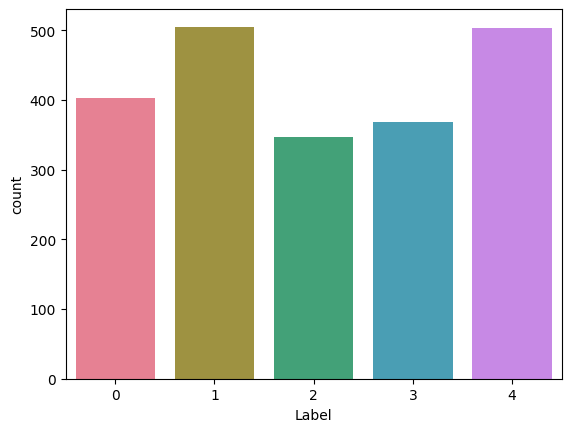

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.countplot(x = df['Label'], palette = 'husl')
plt.show()

In [20]:
df['Length'] = df['Text'].apply(lambda x:len(nltk.word_tokenize(x)))

<ipython-input-20-86b4bca01a0b>:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Length'] = df['Text'].apply(lambda x:len(nltk.word_tokenize(x)))


/usr/local/lib/python3.10/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/usr/local/lib/python3.10/dist-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/usr/local/lib/python3.10/dist-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/usr/local/lib/python3.10/dist-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-l

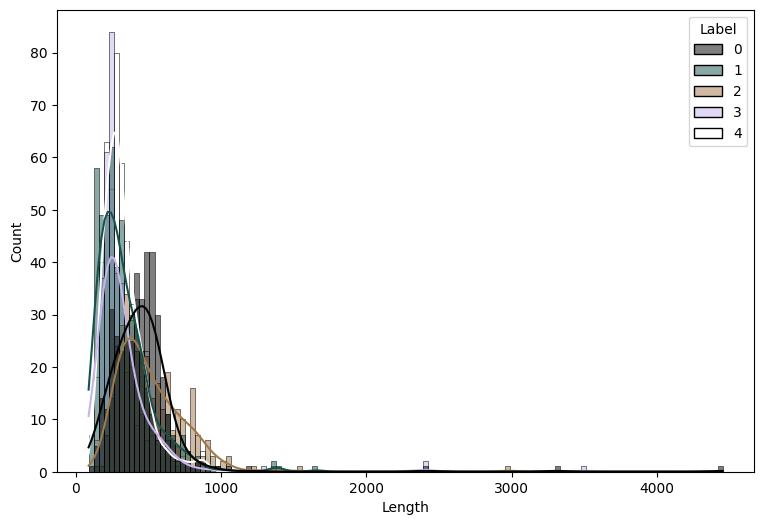

In [21]:
plt.figure(figsize = (9, 6))
sns.histplot(x = df['Length'], kde = True, hue = df['Label'], palette = 'cubehelix')
plt.show()

In [22]:
from wordcloud import WordCloud
wc = WordCloud(width=500, height=500, min_font_size=10)

Viewing the most common words for all labels

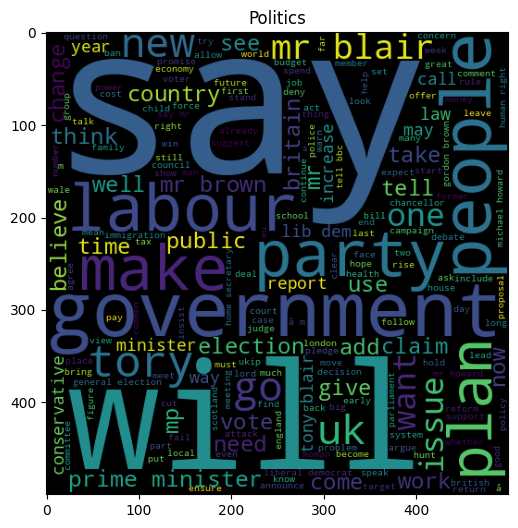

In [23]:
politics = wc.generate(df[df['Label'] == 0]['Text'].str.cat(sep=" "))
plt.figure(figsize=(15,6))
plt.title('Politics')
plt.imshow(politics)
plt.show()

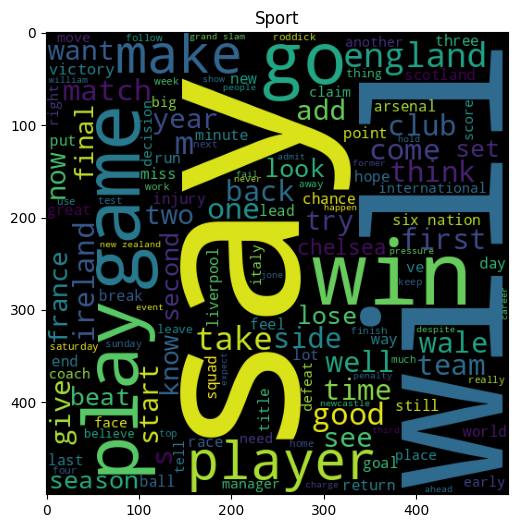

In [24]:
sport = wc.generate(df[df['Label'] == 1]['Text'].str.cat(sep=" "))
plt.figure(figsize=(15,6))
plt.title('Sport')
plt.imshow(sport)
plt.show()

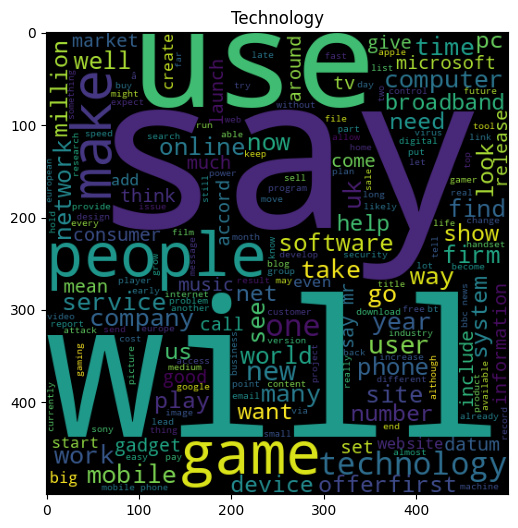

In [25]:
technology = wc.generate(df[df['Label'] == 2]['Text'].str.cat(sep=" "))
plt.figure(figsize=(15,6))
plt.title('Technology')
plt.imshow(technology)
plt.show()

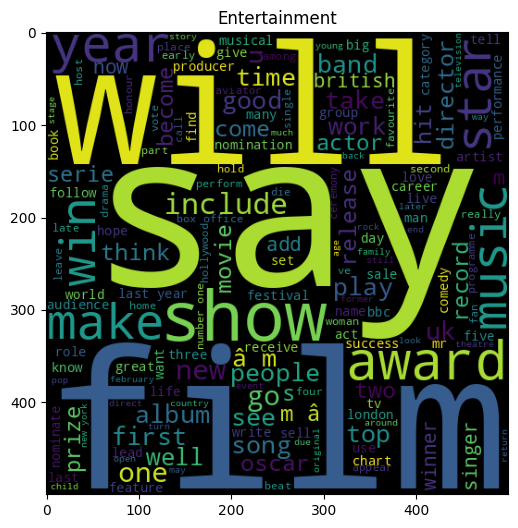

In [26]:
entertainment = wc.generate(df[df['Label'] == 3]['Text'].str.cat(sep=" "))
plt.figure(figsize=(15,6))
plt.title('Entertainment')
plt.imshow(entertainment)
plt.show()

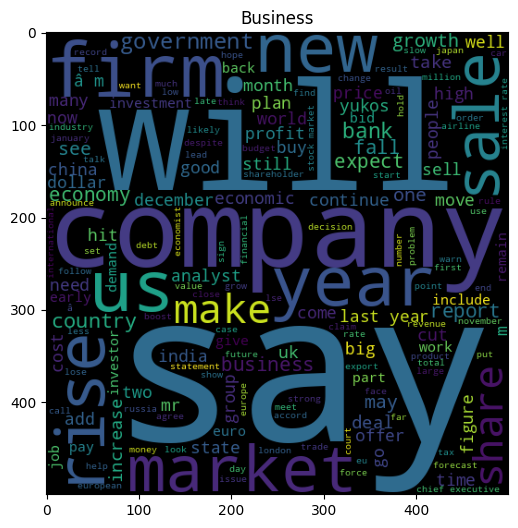

In [27]:
business = wc.generate(df[df['Label'] == 4]['Text'].str.cat(sep=" "))
plt.figure(figsize=(15,6))
plt.title('Business')
plt.imshow(business)
plt.show()

Looks like "say" has a big say in all the topics!

## Model Building

In [28]:
from sklearn.feature_extraction.text import TfidfVectorizer
tfidf = TfidfVectorizer(max_features = 4000)

X = tfidf.fit_transform(df['Text']).toarray()

In [29]:
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()

df['Length'] = sc.fit_transform(df[['Length']])

<ipython-input-29-8f3d3550f99e>:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Length'] = sc.fit_transform(df[['Length']])


In [30]:
X.shape
# this includes only the text

(2127, 4000)

In [31]:
import numpy as np
X1 = np.hstack((X, df['Length'].values.reshape(-1,1)))

In [32]:
X1.shape
# this includes both the text and the length column that we created

(2127, 4001)

In [33]:
y = df['Label'].values

In [34]:
y.shape

(2127,)

In [35]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 5)

Usually Naive Bayes performs well with textual data, so I am testing all three versions of Naive Bayes.

In [36]:
from sklearn.naive_bayes import GaussianNB, MultinomialNB, BernoulliNB
from sklearn.metrics import accuracy_score, confusion_matrix

gnb = GaussianNB()
mnb = MultinomialNB()
bnb = BernoulliNB()

In [37]:
gnb.fit(X_train, y_train)
y_pred1 = gnb.predict(X_test)
print("Accuracy: ", accuracy_score(y_test, y_pred1))
print(confusion_matrix(y_test, y_pred1))

Accuracy:  0.9225352112676056
[[ 67   0   2   3   2]
 [  1 112   1   1   1]
 [  1   0  69   2   1]
 [  3   0   7  71   0]
 [  5   0   2   1  74]]


In [38]:
mnb.fit(X_train, y_train)
y_pred2 = mnb.predict(X_test)
print("Accuracy: ", accuracy_score(y_test, y_pred2))
print(confusion_matrix(y_test, y_pred2))

Accuracy:  0.9647887323943662
[[ 74   0   0   0   0]
 [  0 116   0   0   0]
 [  2   2  66   1   2]
 [  3   0   1  75   2]
 [  2   0   0   0  80]]


In [39]:
bnb.fit(X_train, y_train)
y_pred3 = bnb.predict(X_test)
print("Accuracy: ", accuracy_score(y_test, y_pred3))
print(confusion_matrix(y_test, y_pred3))

Accuracy:  0.9647887323943662
[[ 70   1   0   2   1]
 [  0 115   0   1   0]
 [  0   0  67   1   5]
 [  0   0   4  77   0]
 [  0   0   0   0  82]]


In [40]:
from sklearn.ensemble import RandomForestClassifier

rfc = RandomForestClassifier(n_estimators = 60)
rfc.fit(X_train, y_train)
y_pred4 = rfc.predict(X_test)

print("Accuracy: ", accuracy_score(y_test, y_pred4))
print(confusion_matrix(y_test, y_pred4))

Accuracy:  0.9530516431924883
[[ 69   2   0   0   3]
 [  0 115   0   0   1]
 [  0   2  65   1   5]
 [  0   0   2  76   3]
 [  1   0   0   0  81]]


In [41]:
from sklearn.ensemble import GradientBoostingClassifier

gbc = GradientBoostingClassifier(n_estimators = 100)
gbc.fit(X_train, y_train)
y_pred5 = gbc.predict(X_test)

print("Accuracy: ", accuracy_score(y_test, y_pred5))
print(confusion_matrix(y_test, y_pred5))

Accuracy:  0.9624413145539906
[[ 67   1   1   1   4]
 [  0 115   0   0   1]
 [  0   1  69   0   3]
 [  0   0   2  79   0]
 [  2   0   0   0  80]]


In [42]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(solver='liblinear')
lr.fit(X_train, y_train)
y_pred6 = lr.predict(X_test)

print("Accuracy: ", accuracy_score(y_test, y_pred6))
print(confusion_matrix(y_test, y_pred6))

Accuracy:  0.9788732394366197
[[ 71   1   1   0   1]
 [  0 116   0   0   0]
 [  0   0  70   1   2]
 [  0   0   0  79   2]
 [  1   0   0   0  81]]


In [43]:
X1_train, X1_test, y1_train, y1_test = train_test_split(X1, y, test_size = 0.2, random_state = 47)

In [44]:
gbc.fit(X1_train, y1_train)
y1_pred = gbc.predict(X1_test)
print("Accuracy: ", accuracy_score(y1_test, y1_pred))
print(confusion_matrix(y1_test, y1_pred))

Accuracy:  0.9460093896713615
[[ 74   0   2   2   7]
 [  0 106   0   0   1]
 [  0   1  58   1   2]
 [  0   0   1  70   1]
 [  2   1   1   1  95]]


In [45]:
lr.fit(X1_train, y1_train)
y1_pred2 = lr.predict(X1_test)
print("Accuracy: ", accuracy_score(y1_test, y1_pred2))
print(confusion_matrix(y1_test, y1_pred2))

Accuracy:  0.9577464788732394
[[ 75   0   1   0   9]
 [  0 106   1   0   0]
 [  0   0  61   0   1]
 [  0   0   3  68   1]
 [  1   0   1   0  98]]


The models which use length of text as a feature perform worse, so no need to consider that

In [46]:
from sklearn.ensemble import VotingClassifier

models = [('lr', lr), ('mnb', mnb), ('rfc', rfc), ('bnb', bnb), ('gbc', gbc)]
vote = VotingClassifier(estimators = models)
vote = vote.fit(X_train, y_train)
vote_pred = vote.predict(X_test)

print("Voting Accuracy: ", accuracy_score(y_test, vote_pred))
print(confusion_matrix(y_test, vote_pred))

Voting Accuracy:  0.9741784037558685
[[ 72   1   0   0   1]
 [  0 116   0   0   0]
 [  0   1  68   1   3]
 [  0   0   1  78   2]
 [  1   0   0   0  81]]


So the voting classifier works fine and is our final model.
Thank you!